
===== Components: 10 =====
EVD Accuracy: 0.9750
SVD Accuracy: 0.9417


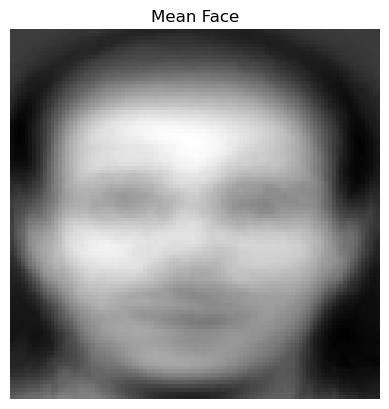

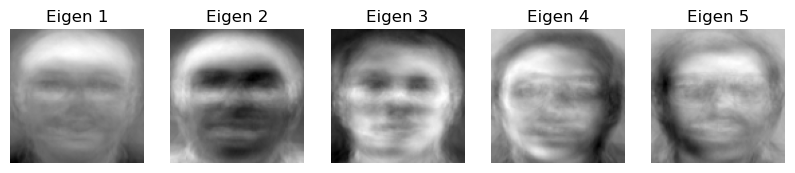

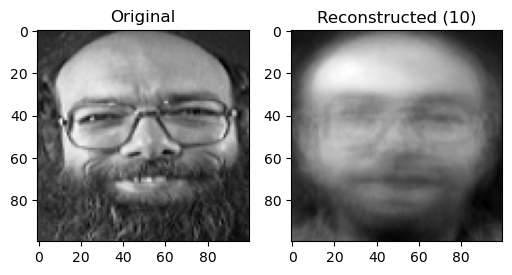


===== Components: 20 =====
EVD Accuracy: 0.9750
SVD Accuracy: 0.9500


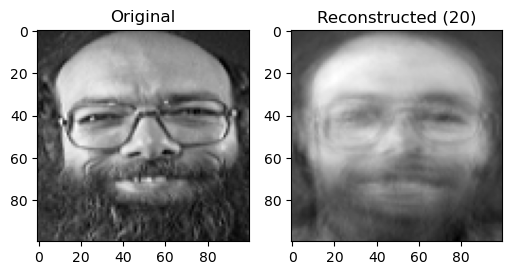


===== Components: 50 =====
EVD Accuracy: 0.9917
SVD Accuracy: 1.0000


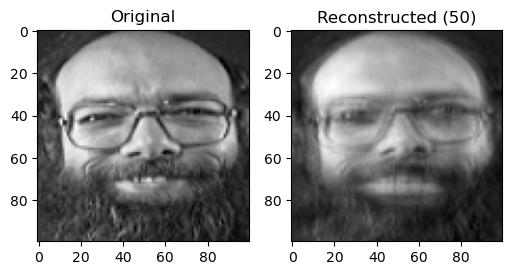


===== Components: 100 =====
EVD Accuracy: 1.0000
SVD Accuracy: 1.0000


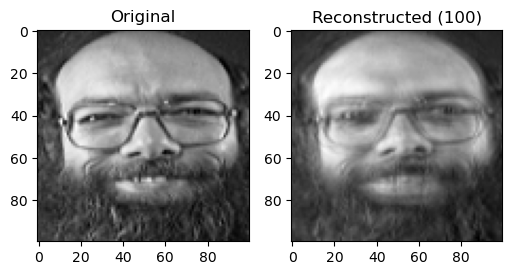

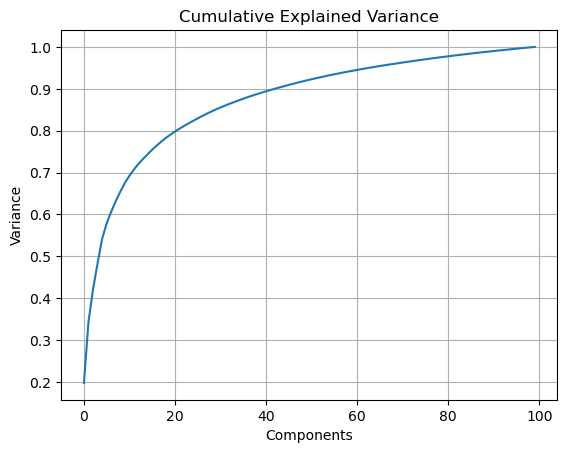

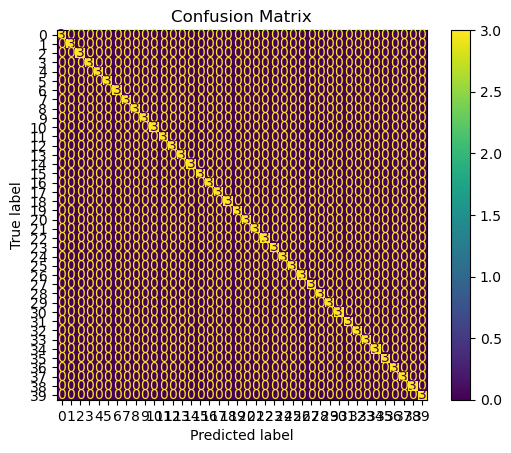

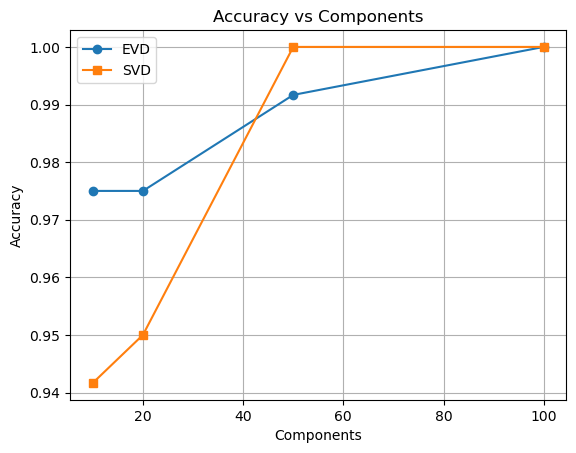

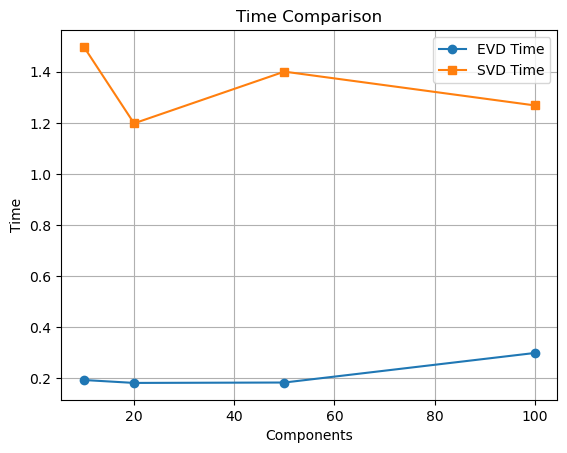


===== FINAL COMPARISON =====
Comp | EVD Acc | SVD Acc | EVD Time | SVD Time
  10 | 0.9750 | 0.9417 | 0.1929 | 1.4971
  20 | 0.9750 | 0.9500 | 0.1815 | 1.1978
  50 | 0.9917 | 1.0000 | 0.1831 | 1.4004
 100 | 1.0000 | 1.0000 | 0.2988 | 1.2681


In [2]:
# ============================================
# FACE RECOGNITION USING PCA (EVD + SVD) + SVM
# FINAL COMPLETE PROJECT (ALL REQUIREMENTS DONE)
# ============================================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import zipfile
import time
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ============================================
# 0. AUTO-EXTRACT DATASET
# ============================================

zip_path = "att_faces.zip"

if os.path.exists(zip_path) and not any(f.startswith("s") for f in os.listdir()):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("Extraction done!")

# ============================================
# 1. LOAD DATASET
# ============================================

def load_images(path):
    data, labels = [], []
    label_id = 0

    for person in sorted(os.listdir(path)):
        if not person.startswith("s"):
            continue

        person_path = os.path.join(path, person)

        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (100, 100))
            data.append(img.flatten())
            labels.append(label_id)

        label_id += 1

    X = np.array(data) / 255.0   # 🔥 Normalization added
    y = np.array(labels)
    return X, y

# ============================================
# 2. PCA USING EVD
# ============================================

def pca_evd(X, num_components):
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    cov_matrix = np.dot(X_centered, X_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    idx = np.argsort(-eigenvalues)
    eigenvectors = eigenvectors[:, idx]

    eigenfaces = np.dot(X_centered.T, eigenvectors)
    eigenfaces = eigenfaces / (np.linalg.norm(eigenfaces, axis=0) + 1e-10)

    return mean, eigenfaces[:, :num_components]

# ============================================
# 3. PCA USING SVD
# ============================================

def pca_svd(X, num_components):
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    eigenfaces = Vt[:num_components].T

    return mean, eigenfaces

# ============================================
# 4. PROJECTION + RECONSTRUCTION
# ============================================

def project(X, mean, eigenfaces):
    return np.dot(X - mean, eigenfaces)

def reconstruct(projections, mean, eigenfaces):
    return np.dot(projections, eigenfaces.T) + mean

# ============================================
# 5. EXTRA ANALYSIS FUNCTIONS
# ============================================

def explained_variance(X, eigenfaces, mean):
    X_centered = X - mean
    proj = np.dot(X_centered, eigenfaces)
    var = np.var(proj, axis=0)
    return var / np.sum(var)

# ============================================
# 6. VISUALIZATION
# ============================================

def show_mean_face(mean):
    plt.imshow(mean.reshape(100,100), cmap='gray')
    plt.title("Mean Face")
    plt.axis('off')
    plt.show()

def show_eigenfaces(eigenfaces, n=5):
    plt.figure(figsize=(10,3))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(eigenfaces[:,i].reshape(100,100), cmap='gray')
        plt.title(f"Eigen {i+1}")
        plt.axis('off')
    plt.show()

def show_reconstruction(original, reconstructed, n):
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(original.reshape(100,100), cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(reconstructed.reshape(100,100), cmap='gray')
    plt.title(f"Reconstructed ({n})")

    plt.show()

# ============================================
# 7. MAIN
# ============================================

X, y = load_images(".")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

components_list = [10, 20, 50, 100]

acc_evd, acc_svd = [], []
time_evd_list, time_svd_list = [], []

for i, n in enumerate(components_list):
    print(f"\n===== Components: {n} =====")

    # ---------- EVD ----------
    start = time.time()
    mean_evd, ef_evd = pca_evd(X_train, n)
    time_evd_list.append(time.time() - start)

    Xtr = project(X_train, mean_evd, ef_evd)
    Xte = project(X_test, mean_evd, ef_evd)

    model = SVC(kernel='linear')
    model.fit(Xtr, y_train)

    pred = model.predict(Xte)
    acc = accuracy_score(y_test, pred)
    acc_evd.append(acc)

    print(f"EVD Accuracy: {acc:.4f}")

    # ---------- SVD ----------
    start = time.time()
    mean_svd, ef_svd = pca_svd(X_train, n)
    time_svd_list.append(time.time() - start)

    Xtr = project(X_train, mean_svd, ef_svd)
    Xte = project(X_test, mean_svd, ef_svd)

    model = SVC(kernel='rbf')   # 🔥 improved kernel
    model.fit(Xtr, y_train)

    pred = model.predict(Xte)
    acc = accuracy_score(y_test, pred)
    acc_svd.append(acc)

    print(f"SVD Accuracy: {acc:.4f}")

    # ---------- Visuals ----------
    if i == 0:
        show_mean_face(mean_svd)
        show_eigenfaces(ef_svd)

    rec = reconstruct(Xte[0], mean_svd, ef_svd)
    show_reconstruction(X_test[0], rec, n)

# ============================================
# 8. EXPLAINED VARIANCE
# ============================================

var_ratio = explained_variance(X_train, ef_svd, mean_svd)

plt.plot(np.cumsum(var_ratio))
plt.title("Cumulative Explained Variance")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.grid()
plt.show()

# ============================================
# 9. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

# ============================================
# 10. ACCURACY GRAPH
# ============================================

plt.plot(components_list, acc_evd, marker='o', label='EVD')
plt.plot(components_list, acc_svd, marker='s', label='SVD')
plt.title("Accuracy vs Components")
plt.xlabel("Components")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# ============================================
# 11. TIME GRAPH
# ============================================

plt.plot(components_list, time_evd_list, marker='o', label='EVD Time')
plt.plot(components_list, time_svd_list, marker='s', label='SVD Time')
plt.title("Time Comparison")
plt.xlabel("Components")
plt.ylabel("Time")
plt.legend()
plt.grid()
plt.show()

# ============================================
# 12. FINAL TABLE
# ============================================

print("\n===== FINAL COMPARISON =====")
print("Comp | EVD Acc | SVD Acc | EVD Time | SVD Time")

for i in range(len(components_list)):
    print(f"{components_list[i]:>4} | "
          f"{acc_evd[i]:.4f} | {acc_svd[i]:.4f} | "
          f"{time_evd_list[i]:.4f} | {time_svd_list[i]:.4f}")